In [1]:


from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"


# from ucimlrepo import fetch_ucirepo

# steel_plates_faults = fetch_ucirepo(id=198)
# X = steel_plates_faults.data.features
# y = steel_plates_faults.data.targets



with open('../steel_plates_faults/Faults27x7_var', 'r') as f:
    nazwy_kolumn = [linia.strip() for linia in f if linia.strip()]

# 2. Wczytanie danych (kolumny rozdzielone białymi znakami)
df = pd.read_csv('../steel_plates_faults/Faults.NNA', header=None, sep=r'\s+', names=nazwy_kolumn)

# 3. Podział na cechy (X) i etykiety (y) dokładnie tak, jak robiło to ucimlrepo
# Pierwsze 27 kolumn to cechy, ostatnie 7 kolumn to etykiety (targets)
X = df.iloc[:, :27]
y = df.iloc[:, 27:]


y = np.argmax(y.values, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).long().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# --- MODEL DLA TESTU K1 ---
class NetK1(nn.Module):
    def __init__(self, k1_size):
        super(NetK1, self).__init__()
        self.fc1 = nn.Linear(27, k1_size)
        self.fc2 = nn.Linear(k1_size, 64) # K2 stałe = 64
        self.fc3 = nn.Linear(64, 7)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# --- KONFIGURACJA ---
k1_values = [32, 64, 128, 256, 512]
num_repeats = 5
epochs = 20
best_lr = 0.001
k1_results = {}

print(f"Rozpoczynam Eksperyment 3a (Urządzenie: {device})")

for k1 in k1_values:
    print(f"\n>>> Testowanie K1 = {k1}")
    run_accs = []
    for i in range(num_repeats):
        model = NetK1(k1).to(device)
        optimizer = optim.Adam(model.parameters(), lr=best_lr)
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(x_batch), y_batch)
                loss.backward()
                optimizer.step()
        
        model.eval()
        with torch.no_grad():
            acc = (model(X_test_tensor).argmax(1) == y_test_tensor).float().mean().item() * 100
            run_accs.append(acc)
            print(f"   Próba {i+1}: {acc:.2f}%")
    k1_results[str(k1)] = run_accs

Rozpoczynam Eksperyment 3a (Urządzenie: cuda)

>>> Testowanie K1 = 32
   Próba 1: 74.55%
   Próba 2: 73.52%
   Próba 3: 73.26%
   Próba 4: 75.58%
   Próba 5: 72.49%

>>> Testowanie K1 = 64
   Próba 1: 76.61%
   Próba 2: 76.09%
   Próba 3: 74.81%
   Próba 4: 75.32%
   Próba 5: 75.06%

>>> Testowanie K1 = 128
   Próba 1: 75.32%
   Próba 2: 75.84%
   Próba 3: 76.61%
   Próba 4: 74.81%
   Próba 5: 74.55%

>>> Testowanie K1 = 256
   Próba 1: 74.55%
   Próba 2: 76.86%
   Próba 3: 76.86%
   Próba 4: 73.78%
   Próba 5: 75.58%

>>> Testowanie K1 = 512
   Próba 1: 76.35%
   Próba 2: 77.63%
   Próba 3: 76.61%
   Próba 4: 75.84%
   Próba 5: 75.84%


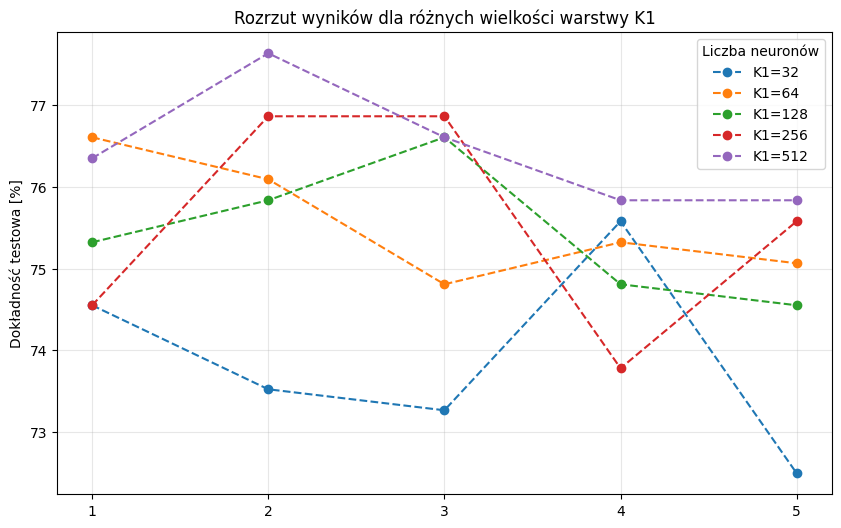

In [2]:
# --- WYKRESY K1 ---
plt.figure(figsize=(10, 6))
for k1_val, accs in k1_results.items():
    plt.plot(range(1, num_repeats + 1), accs, marker='o', linestyle='--', label=f'K1={k1_val}')
plt.title('Rozrzut wyników dla różnych wielkości warstwy K1')
plt.xticks(range(1, num_repeats + 1))
plt.ylabel('Dokładność testowa [%]')
plt.legend(title="Liczba neuronów")
plt.grid(True, alpha=0.3)
plt.show()

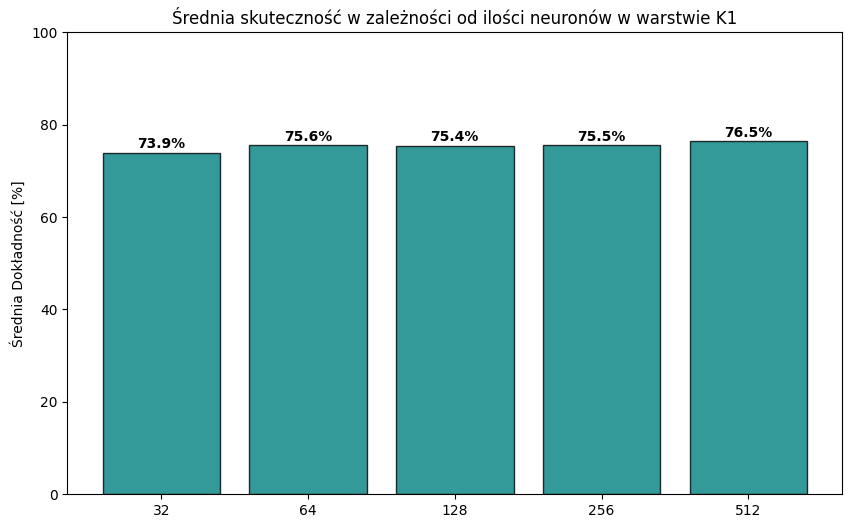

In [3]:
plt.figure(figsize=(10, 6))
k1_means = [np.mean(k1_results[str(k)]) for k in k1_values]
bars = plt.bar([str(k) for k in k1_values], k1_means, color='teal', alpha=0.8, edgecolor='black')
plt.title('Średnia skuteczność w zależności od ilości neuronów w warstwie K1')
plt.ylabel('Średnia Dokładność [%]')
plt.ylim(0, 100)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', fontweight='bold')
plt.show()

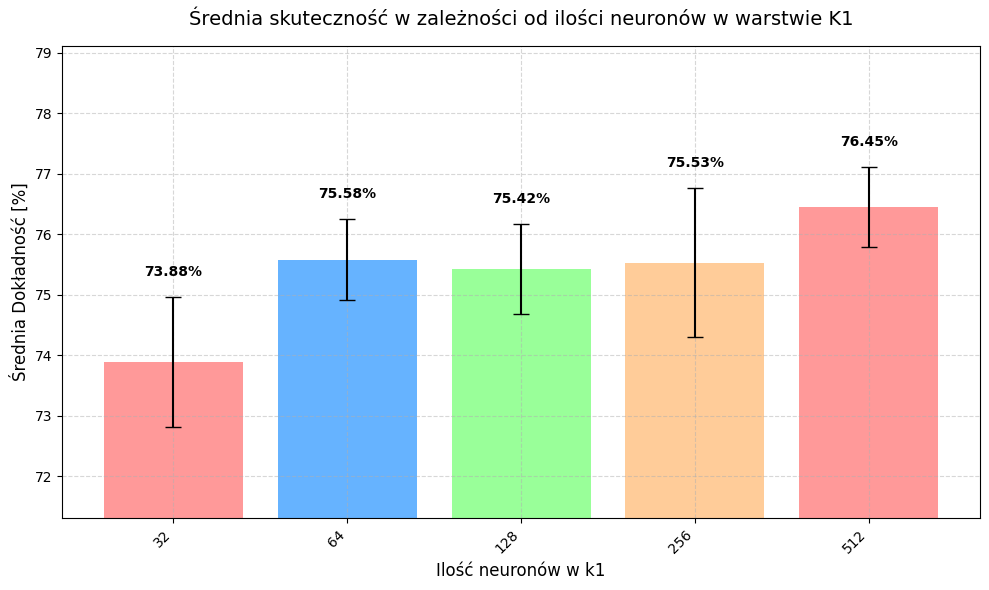

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ==================== GENEROWANIE WYKRESU LINIOWEGO ====================
plt.figure(figsize=(10, 6))

k1_keys = list(k1_results.keys())
k1_means = [np.mean(k1_results[n]) for n in k1_keys]
std = [np.std(k1_results[n]) for n in k1_keys]

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] # Estetyczne kolory słupków

# Rysujemy linie i punkty z wąsami błędu (zamiast słupków)
# fmt='-o' oznacza linię ciągłą z dużymi punktami w miejscach danych
plt.bar(
    k1_keys, 
    k1_means, 
    yerr=std,  
    color=colors,      # Główny kolor linii i punktów
    ecolor='#e74c3c',     # Kolor wąsów błędu (kontrastowy czerwony)
    capsize=6,            # Szerokość poziomych daszków na końcach wąsów
    linewidth=2,          # Grubość linii łączącej punkty
    # label='Średnia dokładność ± SD'
     error_kw={'ecolor': 'black', 'elinewidth': 1.5}
)

plt.title('Średnia skuteczność w zależności od ilości neuronów w warstwie K1', fontsize=14, pad=15)
plt.ylabel('Średnia Dokładność [%]', fontsize=12)
plt.xlabel('Ilość neuronów w k1', fontsize=12)

# Dynamiczne skalowanie osi Y dopasowane do rozrzutu danych
ymin = min([s - o for s, o in zip(k1_means, std)]) - 1.5
ymax = max([s + o for s, o in zip(k1_means, std)]) + 2.0  # zapas na etykiety tekstowe
plt.ylim(ymin, ymax)

plt.grid(axis='both', linestyle='--', alpha=0.5) # Siatka w obie strony pomaga odczytać punkty

# Dodawanie etykiet tekstowych z wartościami obok/nad punktami
# for i, txt in enumerate(k1_means):
#     plt.text(
#         k1_means[i], 
#         k1_means[i] + std[i] + 0.3, # Umieszcza tekst 0.3% powyżej górnego wąsa błędu
#         f'{txt:.2f}%', 
#         ha='center', 
#         va='bottom', 
#         fontweight='bold',
#         fontsize=10
#     )

# Obrót podpisów osi X, aby były czytelne przy długich nazwach konfiguracji
plt.xticks(rotation=45, ha='right')
# plt.legend(loc='upper right')

for i, bar in enumerate(bars):
    yval = bar.get_height()
    sd = std[i]
    
    # Pozycja tekstu: wysokość słupka + długość wąsa + mały odstęp
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + sd + 0.3, # 0.3% powyżej górnego wąsa błędu
        f'{yval:.2f}%', 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()